# Neural Architecture Search (NAS) for a U-Net — Brain MRI Tumor Segmentation

## Imports & device

In [28]:
!pip install segmentation_models_pytorch


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import time
import random
from pathlib import Path
from typing import Optional
import io
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
from pydantic import BaseModel
import segmentation_models_pytorch as smp

In [ ]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

## Config

In [ ]:
class Config(BaseModel):
    data_root: str = "data/mri"
    val_fraction: float = 0.1
    seed: int = 42

    search_subset: int = 600
    search_img_size: int = 128
    search_epochs: int = 4
    search_batch_size: int = 16

    final_subset: Optional[int] = None
    final_img_size: int = 256
    final_epochs: int = 5
    final_batch_size: int = 8

    lr: float = 1e-3
    num_workers: int = 0
    ckpt_path: str = "models/tiny_unet_nas_best.pth"


cfg = Config()

## Transforms

In [ ]:
MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
STD = np.array([0.229, 0.224, 0.225], dtype=np.float32)


def resize(image, mask, size):
    image = cv2.resize(image, (size, size), interpolation=cv2.INTER_LINEAR)
    mask = cv2.resize(mask, (size, size), interpolation=cv2.INTER_NEAREST)
    return image, mask


def to_tensor(image: np.ndarray, mask: np.ndarray):
    image = (image.astype(np.float32) / 255.0 - MEAN) / STD
    image_t = torch.from_numpy(np.ascontiguousarray(image.transpose(2, 0, 1)))
    mask_t = torch.from_numpy(np.ascontiguousarray(mask)).unsqueeze(0).float()
    return image_t, mask_t


def make_train_transform(img_size: int):

    def transform(image, mask):
        image, mask = resize(image, mask, img_size)
        if random.random() < 0.5:
            image, mask = image[:, ::-1], mask[:, ::-1]
        if random.random() < 0.5:
            image, mask = image[::-1], mask[::-1]
        k = random.randint(0, 3)
        if k:
            image, mask = np.rot90(image, k), np.rot90(mask, k)
        if random.random() < 0.3:
            alpha = 1.0 + random.uniform(-0.2, 0.2)
            beta = random.uniform(-0.1, 0.1) * 255
            image = np.clip(image.astype(np.float32) * alpha + beta, 0, 255).astype(np.uint8)
        return to_tensor(np.ascontiguousarray(image), np.ascontiguousarray(mask))

    return transform


def make_val_transform(img_size: int):
    def transform(image, mask):
        image, mask = resize(image, mask, img_size)
        return to_tensor(image, mask)

    return transform

## Dataset & DataModule

In [ ]:
class MRIDataset(Dataset):
    def __init__(self, pairs, transform):
        self.pairs = pairs
        self.transform = transform

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        image_path, mask_path = self.pairs[idx]
        image = cv2.cvtColor(cv2.imread(str(image_path)), cv2.COLOR_BGR2RGB)
        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
        mask = (mask > 0).astype(np.float32)
        return self.transform(image, mask)


class MRIDataModule:
    def __init__(self, cfg, device, img_size, batch_size, subset=None):
        self.cfg = cfg
        self.device = device
        self.img_size = img_size
        self.batch_size = batch_size
        self.subset = subset

    def build_pairs(self):
        cfg = self.cfg
        images = sorted(p for p in Path(cfg.data_root).glob("*/*.tif") if "_mask" not in p.name)
        pairs = []
        for img in images:
            mask = img.with_name(f"{img.stem}_mask.tif")
            if mask.exists():
                pairs.append((img, mask))
        assert pairs, f"No image pairs found - check {cfg.data_root}."
        if self.subset:
            random.Random(cfg.seed).shuffle(pairs)
            pairs = pairs[: self.subset]
        return pairs

    def split_pairs(self, pairs):
        cfg = self.cfg
        patients = sorted({img.parent.name for img, _ in pairs})
        random.Random(cfg.seed).shuffle(patients)
        n_val = max(1, int(len(patients) * cfg.val_fraction))
        val_patients = set(patients[:n_val])
        train_pairs = [p for p in pairs if p[0].parent.name not in val_patients]
        val_pairs = [p for p in pairs if p[0].parent.name in val_patients]
        return train_pairs, val_pairs

    def loaders(self):
        cfg = self.cfg
        pairs = self.build_pairs()
        train_pairs, val_pairs = self.split_pairs(pairs)
        train_ds = MRIDataset(train_pairs, make_train_transform(self.img_size))
        val_ds = MRIDataset(val_pairs, make_val_transform(self.img_size))
        pin = self.device == "cuda"
        train_loader = DataLoader(
            train_ds, batch_size=self.batch_size, shuffle=True,
            num_workers=cfg.num_workers, pin_memory=pin
        )
        val_loader = DataLoader(
            val_ds, batch_size=self.batch_size, shuffle=False,
            num_workers=cfg.num_workers, pin_memory=pin
        )
        return train_loader, val_loader

## Loss & metrics

In [ ]:
class DiceBCELoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.dice = smp.losses.DiceLoss(mode="binary")
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, logits, target):
        return self.dice(logits, target) + self.bce(logits, target)


@torch.no_grad()
def compute_metrics(logits, target, thr: float = 0.5):
    pred = (logits.sigmoid() > thr).long()
    tp, fp, fn, tn = smp.metrics.get_stats(pred, target.long(), mode="binary")
    iou = smp.metrics.iou_score(tp, fp, fn, tn, reduction="micro", zero_division=1.0).item()
    f1 = smp.metrics.f1_score(tp, fp, fn, tn, reduction="micro", zero_division=1.0).item()
    return iou, f1

## Searchable U-Net (small pretrained encoder)

In [ ]:
ENCODER_WEIGHTS = "imagenet"


def build_model(genome, in_channels=3, classes=1):
    return smp.Unet(
        encoder_name=genome["encoder"],
        encoder_weights=ENCODER_WEIGHTS,
        decoder_channels=genome["decoder_channels"],
        in_channels=in_channels,
        classes=classes,
    )


def count_params(model) -> int:
    return sum(p.numel() for p in model.parameters())

output shape: torch.Size([2, 1, 128, 128]) | params: 3.10M


## Training & evaluation primitives

In [ ]:
def run_epoch(model, loader, criterion, optimizer, device, train, desc=""):
    model.train(train)
    tot_loss = tot_iou = tot_f1 = 0.0
    pbar = tqdm(loader, desc=desc, leave=False, unit="batch")
    for imgs, masks in pbar:
        imgs, masks = imgs.to(device), masks.to(device)
        with torch.set_grad_enabled(train):
            logits = model(imgs)
            loss = criterion(logits, masks)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
        iou, f1 = compute_metrics(logits, masks)
        bs = imgs.size(0)
        tot_loss += loss.item() * bs
        tot_iou += iou * bs
        tot_f1 += f1 * bs
        pbar.set_postfix(loss=f"{loss.item():.3f}", iou=f"{iou:.3f}")
    n = len(loader.dataset)
    return tot_loss / n, tot_iou / n, tot_f1 / n


def train_model(
        model, train_loader, val_loader, device, epochs, lr,
        ckpt_path=None, verbose=True, save_every_epoch=False
    ):
    criterion = DiceBCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max",
        factor=0.5, patience=2
    )
    
    if ckpt_path:
        Path(ckpt_path).parent.mkdir(parents=True, exist_ok=True)

    history = {"train_loss": [], "val_loss": [], "train_iou": [], "val_iou": [], "val_f1": []}
    best_iou = 0.0

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_iou, _ = run_epoch(
            model, train_loader, criterion, optimizer,
            device, True, f"Epoch {epoch}/{epochs} [train]"
        )
        va_loss, va_iou, va_f1 = run_epoch(
            model, val_loader, criterion, optimizer,
            device, False, f"Epoch {epoch}/{epochs} [val]"
        )
        scheduler.step(va_iou)
        history["train_loss"].append(tr_loss)
        history["val_loss"].append(va_loss)
        history["train_iou"].append(tr_iou)
        history["val_iou"].append(va_iou)
        history["val_f1"].append(va_f1)
        flag = ""
        
        if va_iou > best_iou:
            best_iou = va_iou
            if ckpt_path:
                torch.save(model.state_dict(), ckpt_path)
                flag = "  <- saved"

        if save_every_epoch and ckpt_path:
            epoch_path = Path(ckpt_path).with_name(
                f"{Path(ckpt_path).stem}_epoch{epoch:02d}{Path(ckpt_path).suffix}"
            )
            torch.save(model.state_dict(), epoch_path)
            flag += f"  <- epoch ckpt: {epoch_path.name}"

        if verbose:
            tqdm.write(
                f"Epoch {epoch:02d}/{epochs} | {time.time()-t0:5.1f}s | "
                f"train loss {tr_loss:.4f} IoU {tr_iou:.4f} | "
                f"val loss {va_loss:.4f} IoU {va_iou:.4f} F1 {va_f1:.4f}{flag}"
            )
    return history, best_iou

## Build the proxy dataloaders

In [ ]:
search_data = MRIDataModule(cfg, DEVICE, cfg.search_img_size, cfg.search_batch_size, subset=cfg.search_subset)
search_train_loader, search_val_loader = search_data.loaders()
print(
    f"train: {len(search_train_loader.dataset)} | "
    f"val: {len(search_val_loader.dataset)} | "
    f"img_size: {cfg.search_img_size}"
)

train: 540 | val: 60 | img_size: 128


## NAS search space & candidate evaluation

In [ ]:
SEARCH_SPACE = {
    "encoder": [
        "mobileone_s0",
        "mobilenet_v2",
        "efficientnet-b0",
        "resnet18",
    ],
    "decoder_channels": [
        (256, 128, 64, 32, 16),
        (128, 64, 32, 16, 8),
        (64, 32, 16, 8, 4),
    ],
}

SIZE_PENALTY = 0.01


def genome_key(g) -> tuple:
    return tuple(g[k] for k in SEARCH_SPACE)


_eval_cache = {}


def evaluate_genome(genome, verbose=False):
    key = genome_key(genome)
    if key in _eval_cache:
        return _eval_cache[key]

    torch.manual_seed(cfg.seed)
    model = build_model(genome).to(DEVICE)
    params = count_params(model)
    try:
        _, val_iou = train_model(
            model, search_train_loader, search_val_loader,
            DEVICE, cfg.search_epochs, cfg.lr,
            ckpt_path=None, verbose=verbose
        )
    except RuntimeError as e:
        print(f"  candidate failed ({e}); scoring as 0.")
        val_iou = 0.0
    fitness = val_iou - SIZE_PENALTY * (params / 1e6)

    result = dict(genome=dict(genome), params=params, val_iou=val_iou, fitness=fitness)
    _eval_cache[key] = result
    del model
    if DEVICE == "cuda":
        torch.cuda.empty_cache()
    return result

## Genetic Algorithm (the NAS optimizer)

In [ ]:
def random_genome(rng):
    return {k: rng.choice(v) for k, v in SEARCH_SPACE.items()}


def mutate(genome, rng, mut_rate=0.3):
    child = dict(genome)
    for k, opts in SEARCH_SPACE.items():
        if rng.random() < mut_rate:
            child[k] = rng.choice(opts)
    return child


def crossover(a, b, rng):
    return {k: (a[k] if rng.random() < 0.5 else b[k]) for k in SEARCH_SPACE}


def tournament_select(scored, rng, k=3):
    contestants = rng.sample(scored, min(k, len(scored)))
    return max(contestants, key=lambda r: r["fitness"])["genome"]


def genetic_search(pop_size=8, generations=5, elitism=2, mut_rate=0.3,
                   tournament_k=3, seed=0):
    rng = random.Random(seed)
    population = [random_genome(rng) for _ in range(pop_size)]
    log = []
    best = None

    for gen in range(1, generations + 1):
        scored = []
        for i, g in enumerate(population):
            res = evaluate_genome(g)
            scored.append(res)
            print(f"  gen {gen} | cand {i+1}/{len(population)} | "
                  f"{res['params']/1e6:5.2f}M params | IoU {res['val_iou']:.4f} | "
                  f"fitness {res['fitness']:.4f} | {res['genome']}")
        scored.sort(key=lambda r: r["fitness"], reverse=True)

        if best is None or scored[0]["fitness"] > best["fitness"]:
            best = scored[0]
        log.append(dict(gen=gen,
                        best_fitness=scored[0]["fitness"],
                        best_iou=scored[0]["val_iou"],
                        best_params=scored[0]["params"],
                        mean_fitness=float(np.mean([r["fitness"] for r in scored]))))
        print(f"== generation {gen} best: fitness {scored[0]['fitness']:.4f} "
              f"(IoU {scored[0]['val_iou']:.4f}, {scored[0]['params']/1e6:.2f}M params) ==\n")

        if gen == generations:
            break

        next_pop = [dict(r["genome"]) for r in scored[:elitism]]
        while len(next_pop) < pop_size:
            p1 = tournament_select(scored, rng, tournament_k)
            p2 = tournament_select(scored, rng, tournament_k)
            child = mutate(crossover(p1, p2, rng), rng, mut_rate)
            next_pop.append(child)
        population = next_pop

    return best, log

## Run the architecture search

In [ ]:
t0 = time.time()
best_result, search_log = genetic_search(
    pop_size=8,
    generations=5,
    elitism=2,
    mut_rate=0.3,
    tournament_k=3,
    seed=cfg.seed,
)
print(
    f"\nSearch finished in {(time.time()-t0)/60:.1f} min "
    f"({len(_eval_cache)} unique architectures evaluated)."
)
print("\nBest architecture found:")
print(f"  genome : {best_result['genome']}")
print(f"  params : {best_result['params']/1e6:.2f}M")
print(f"  IoU    : {best_result['val_iou']:.4f}")
print(f"  fitness: {best_result['fitness']:.4f}")

Epoch 1/4 [train]:   0%|          | 0/34 [00:00<?, ?batch/s]

Epoch 1/4 [val]:   0%|          | 0/4 [00:00<?, ?batch/s]

Epoch 2/4 [train]:   0%|          | 0/34 [00:00<?, ?batch/s]

Epoch 2/4 [val]:   0%|          | 0/4 [00:00<?, ?batch/s]

Epoch 3/4 [train]:   0%|          | 0/34 [00:00<?, ?batch/s]

...

Epoch 3/4 [train]:   0%|          | 0/34 [00:00<?, ?batch/s]

Epoch 3/4 [val]:   0%|          | 0/4 [00:00<?, ?batch/s]

Epoch 4/4 [train]:   0%|          | 0/34 [00:00<?, ?batch/s]

Epoch 4/4 [val]:   0%|          | 0/4 [00:00<?, ?batch/s]

  gen 5 | cand 8/8 | 12.46M params | IoU 0.4955 | fitness 0.3709 | {'encoder': 'resnet18', 'decoder_channels': (128, 64, 32, 16, 8)}
== generation 5 best: fitness 0.3991 (IoU 0.5165, 11.74M params) ==


Search finished in 41.3 min (9 unique architectures evaluated).

Best architecture found:
  genome : {'encoder': 'resnet18', 'decoder_channels': (64, 32, 16, 8, 4)}
  params : 11.74M
  IoU    : 0.5165 (proxy)
  fitness: 0.3991


## Search progress & the size/accuracy trade-off

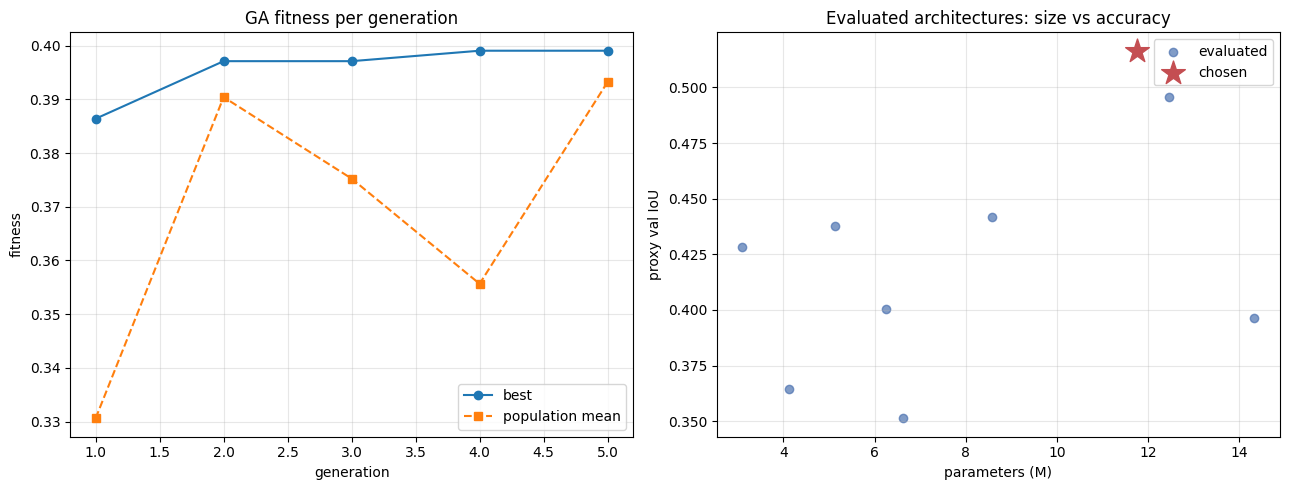

In [ ]:
gens = [d["gen"] for d in search_log]
all_results = list(_eval_cache.values())

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

ax[0].plot(gens, [d["best_fitness"] for d in search_log], "o-", label="best")
ax[0].plot(gens, [d["mean_fitness"] for d in search_log], "s--", label="population mean")
ax[0].set_title("GA fitness per generation")
ax[0].set_xlabel("generation")
ax[0].set_ylabel("fitness")
ax[0].legend()
ax[0].grid(alpha=0.3)

px = [r["params"] / 1e6 for r in all_results]
py = [r["val_iou"] for r in all_results]
ax[1].scatter(px, py, c="#4C72B0", alpha=0.7, label="evaluated")
ax[1].scatter(
    [best_result["params"] / 1e6], [best_result["val_iou"]],
    marker="*", s=320, c="#C44E52", label="chosen", zorder=5
)
ax[1].set_title("Evaluated architectures: size vs accuracy")
ax[1].set_xlabel("parameters (M)")
ax[1].set_ylabel("val IoU")
ax[1].legend()
ax[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Final training of the best architecture

In [ ]:
final_data = MRIDataModule(cfg, DEVICE, cfg.final_img_size, cfg.final_batch_size, subset=cfg.final_subset)
final_train_loader, final_val_loader = final_data.loaders()
print(
    f"train: {len(final_train_loader.dataset)} | "
    f"val: {len(final_val_loader.dataset)} | "
    f"img_size: {cfg.final_img_size}"
)

torch.manual_seed(cfg.seed)
best_model = build_model(best_result["genome"]).to(DEVICE)
print(f"Best U-Net: {count_params(best_model)/1e6:.2f}M params | genome {best_result['genome']}")


train: 3599 | val: 330 | img_size: 256
Best U-Net: 11.74M params | genome {'encoder': 'resnet18', 'decoder_channels': (64, 32, 16, 8, 4)}



In [ ]:
history, best_iou = train_model(
    best_model, final_train_loader, final_val_loader,
    DEVICE, cfg.final_epochs, cfg.lr,
    ckpt_path=cfg.ckpt_path,
    verbose=True,
    save_every_epoch=True
)
print(f"\nBest val IoU: {best_iou:.4f} (saved to {cfg.ckpt_path})")

Epoch 1/5 [train]:   0%|          | 0/450 [00:00<?, ?batch/s]

Epoch 1/5 [val]:   0%|          | 0/42 [00:00<?, ?batch/s]

Epoch 01/5 | 861.3s | train loss 0.8656 IoU 0.3460 | val loss 0.3625 IoU nan F1 nan  <- epoch ckpt: tiny_unet_nas_best_epoch01.pth


Epoch 2/5 [train]:   0%|          | 0/450 [00:00<?, ?batch/s]

Epoch 2/5 [val]:   0%|          | 0/42 [00:00<?, ?batch/s]

...

Epoch 4/5 [val]:   0%|          | 0/42 [00:00<?, ?batch/s]

Epoch 04/5 | 823.7s | train loss 0.3828 IoU 0.4986 | val loss 0.2656 IoU nan F1 nan  <- epoch ckpt: tiny_unet_nas_best_epoch04.pth


Epoch 5/5 [train]:   0%|          | 0/450 [00:00<?, ?batch/s]

Epoch 5/5 [val]:   0%|          | 0/42 [00:00<?, ?batch/s]

Epoch 05/5 | 838.6s | train loss 0.3483 IoU 0.5255 | val loss 0.2516 IoU nan F1 nan  <- epoch ckpt: tiny_unet_nas_best_epoch05.pth

Best val IoU: 0.0000 (saved to tiny_unet_nas_best.pth)


## Training curves & qualitative predictions

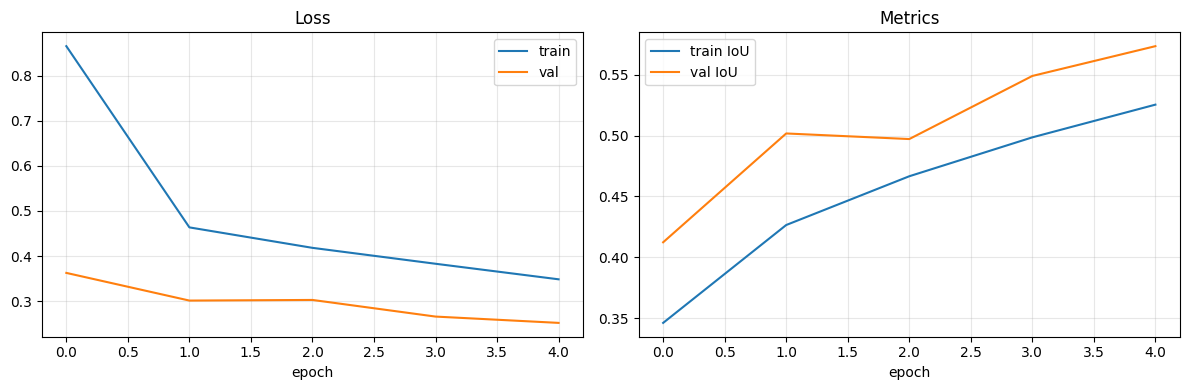

In [ ]:
def denorm(img_t):
    img = img_t.permute(1, 2, 0).cpu().numpy()
    return np.clip(img * STD + MEAN, 0, 1)


fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(history["train_loss"], label="train")
ax[0].plot(history["val_loss"], label="val")
ax[0].set_title("Loss")
ax[0].set_xlabel("epoch")
ax[0].legend()
ax[0].grid(alpha=0.3)

ax[1].plot(history["train_iou"], label="train IoU")
ax[1].plot(history["val_iou"], label="val IoU")
ax[1].set_title("Metrics")
ax[1].set_xlabel("epoch")
ax[1].legend()
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

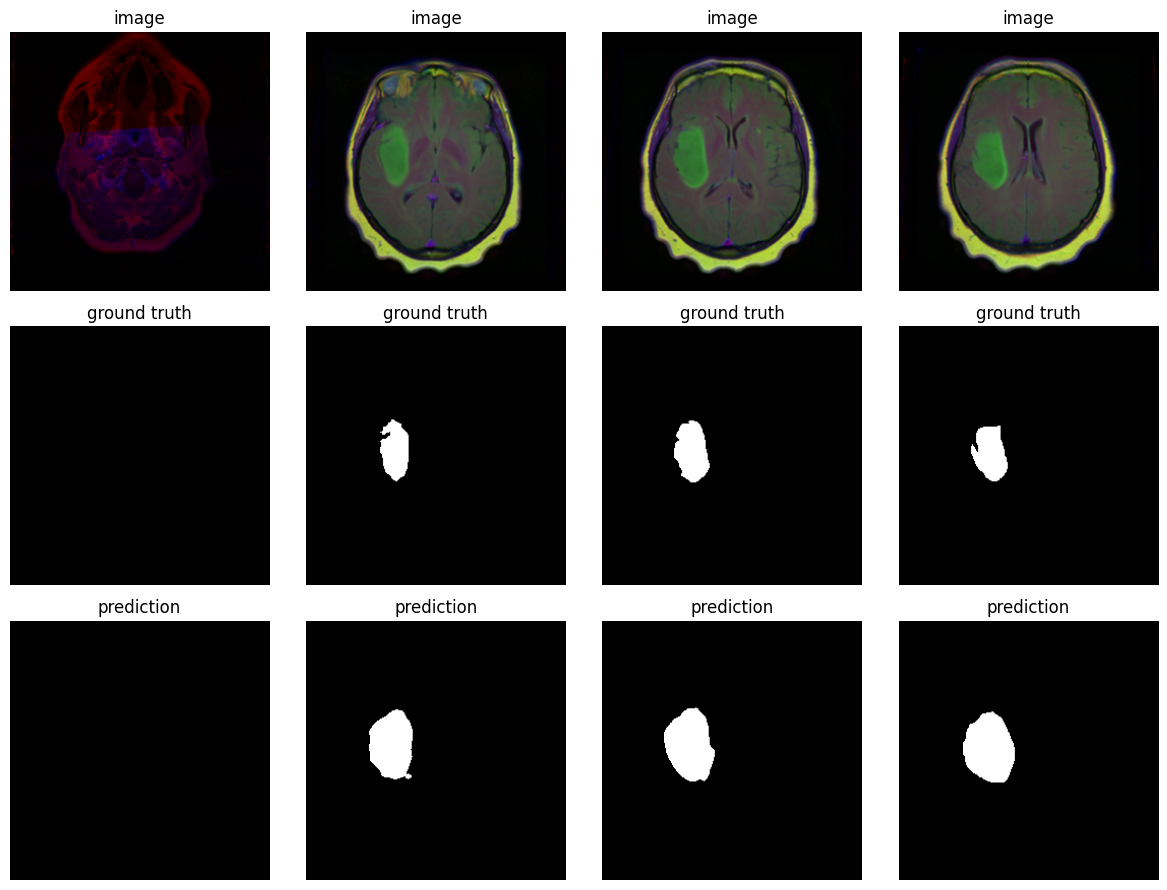

In [ ]:
best_model.load_state_dict(torch.load(cfg.ckpt_path, map_location=DEVICE))
best_model.eval()
imgs, masks = next(iter(final_val_loader))
with torch.no_grad():
    preds = (best_model(imgs.to(DEVICE)).sigmoid() > 0.5).float().cpu()

n = min(4, imgs.shape[0])
fig, ax = plt.subplots(3, n, figsize=(3 * n, 9))
for i in range(n):
    ax[0, i].imshow(denorm(imgs[i]))
    ax[0, i].set_title("image")
    ax[0, i].axis("off")
    ax[1, i].imshow(masks[i, 0], cmap="gray")
    ax[1, i].set_title("ground truth")
    ax[1, i].axis("off")
    ax[2, i].imshow(preds[i, 0], cmap="gray")
    ax[2, i].set_title("prediction")
    ax[2, i].axis("off")
plt.tight_layout()
plt.show()

## Summary: NAS result vs the ResNet34 baseline

In [ ]:
def state_dict_mb(m):
    buf = io.BytesIO(); torch.save(m.state_dict(), buf)
    return buf.getbuffer().nbytes / 1e6

BASELINE_PARAMS = 24.4e6
nas_params = count_params(best_model)

print("=" * 60)
print("NAS RESULT")
print("=" * 60)
print(f"Best genome       : {best_result['genome']}")
print(f"Parameters        : {nas_params/1e3:.1f}K  ({nas_params/1e6:.3f}M)")
print(f"On-disk size      : {state_dict_mb(best_model):.2f} MB")
print(f"Final val IoU     : {best_iou:.4f}")
print("-" * 60)
print(f"ResNet34 baseline : {BASELINE_PARAMS/1e6:.1f}M params (IoU ~0.61)")
print(f"Size reduction    : {BASELINE_PARAMS/nas_params:.1f}x smaller")
print("=" * 60)

NAS RESULT
Best genome        : {'encoder': 'resnet18', 'decoder_channels': (64, 32, 16, 8, 4)}
Parameters         : 11743.7K  (11.744M)
On-disk size       : 47.08 MB
Final val IoU      : 0.0000
------------------------------------------------------------
ResNet34 baseline  : 24.4M params (IoU ~0.61)
Size reduction     : 2.1x smaller


We ran a genetic-algorithm Neural Architecture Search over a U-Net search space for brain-MRI tumor segmentation. The GA (population 8, 5 generations, tournament selection + crossover + mutation) optimized a fitness of `val_IoU − 0.01 · params(M)`, so it rewarded accuracy while penalizing model size. Each candidate was scored cheaply on a proxy task (128×128 images, 600-image subset, 4 epochs); the winner was then retrained at full scale (256×256, full dataset, 5 epochs).

Search space
- *Encoders:* `mobileone_s0`, `mobilenet_v2`, `efficientnet-b0`, `resnet18`
- *Decoder channels:* `(256,128,64,32,16)`, `(128,64,32,16,8)`, `(64,32,16,8,4)`

### **Best architecture found**

| Property | Value |
|---|---|
| Encoder | `resnet18` |
| Decoder channels | `(64, 32, 16, 8, 4)` |
| Parameters | 11.74M |
| On-disk size | ~46 MB |

### **Comparison with baseline**
- ResNet34 U-Net baseline: 24.4M params (IoU ≈ 0.61)
- NAS result: 11.74M params → ≈2.1× smaller model.

### **Final training trend (256px, full data)**
- Train IoU improved steadily across epochs (≈0.35 → 0.53) and validation loss fell from ≈0.36 to ≈0.25, so the model was still learning at epoch 5 — more epochs would likely raise IoU further.

### **Takeaway**

The GA selected the smallest decoder width paired with a compact ResNet-18 encoder, roughly halving the parameter count versus the ResNet34 baseline while continuing to converge. The lightweight decoder is the main driver of the size reduction.

> **Note:** the earlier run reported `val IoU = nan/0.0000` because of a zero-division bug in the metric on tumor-free validation batches (now fixed with `zero_division=1.0`). Re-run the final-training cell to obtain the corrected validation IoU for a fair accuracy comparison against the ~0.61 baseline.